# AI Test

Goal: to detect and classify two types of beads from the images.
- We call the beads "live" and "dead" beads as they simulate live and dead cells. The "live" beads are bigger than "dead" beads.
- The label images (i.e. masks) have two channels, with channel 0 = live and 1 = dead.
- Each object in a mask is represented by a different pixel value.
- Input image size = 1 x 256 x 256, mask image size = 2 x 256 x 256.

Requirements:
- Your task is to complete this script for training and infering with a MaskRCNN model.
- You'll need a GPU and CUDA to speed up training. You can use your own setup, or use Google Colab.
- No need for hyperparameter tuning, so use train/test split (no validation) is enough.
- There are 2 optional bonus tasks to complete, if you have time.

Tips:
- A helper script `helper.py`, and some example snippets are provided. These will help with completing the script.
- All images are TIFF, which you can open by using `skimage.io` from `scikit-image`.


## Google Colab
If you use Google Colab, you'll need to enable GPUs for the notebook:
1. Navigate to Edit → Notebook Settings
2. Select GPU from the Hardware Accelerator drop-down

You'll also need to upload some files:
1. On the left-hand side bar, choose the folder icon (fourth one down).
2. Select Upload icon (First on the left under the text "Files").
3. Navigate to and select `helper.py`, `data.zip`, then press Open.
4. Run the command `unzip data.zip`.



Copyright © 2021 Solentim Ltd.

In [ ]:
# Restart the runtime
from google.colab import runtime
runtime.unassign()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Luke')  

In [ ]:
from skimage import io
import os
import math
import numpy as np
from skimage import io
import torch
from matplotlib import pyplot as plt
import helper
import numpy as np
import torch
from scipy.sparse import csr_matrix
from skimage.draw import rectangle_perimeter
import helper
import datetime


In [ ]:
helper.__file__

'/content/drive/MyDrive/Luke/helper.py'

In [ ]:
torch.cuda.is_available()

True

In [ ]:
example_input = io.imread('/content/drive/MyDrive/Luke//data/input/bead_002.tif') 
example_mask  = io.imread('/content/drive/MyDrive/Luke/data/mask/bead_002.tif')

array([[143, 140, 139, ..., 142, 144, 145],
       [141, 139, 140, ..., 144, 144, 143],
       [139, 139, 141, ..., 145, 145, 143],
       ...,
       [129, 129, 130, ..., 143, 142, 145],
       [130, 132, 129, ..., 144, 146, 142],
       [130, 130, 129, ..., 145, 144, 145]], dtype=uint8)
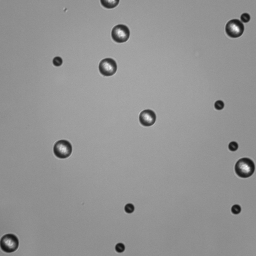

In [ ]:
example_input

In [ ]:
print(f'Input shape: {example_input.shape}')
print(f'Mask shape: {example_mask.shape}')

Input shape: (256, 256)
Mask shape: (2, 256, 256)


In [ ]:
# add a 0th dimension
example_input = np.array([example_input])

In [ ]:
example_input.shape

(1, 256, 256)

Text(0.5, 1.0, 'Mask channel 1 (dead)')

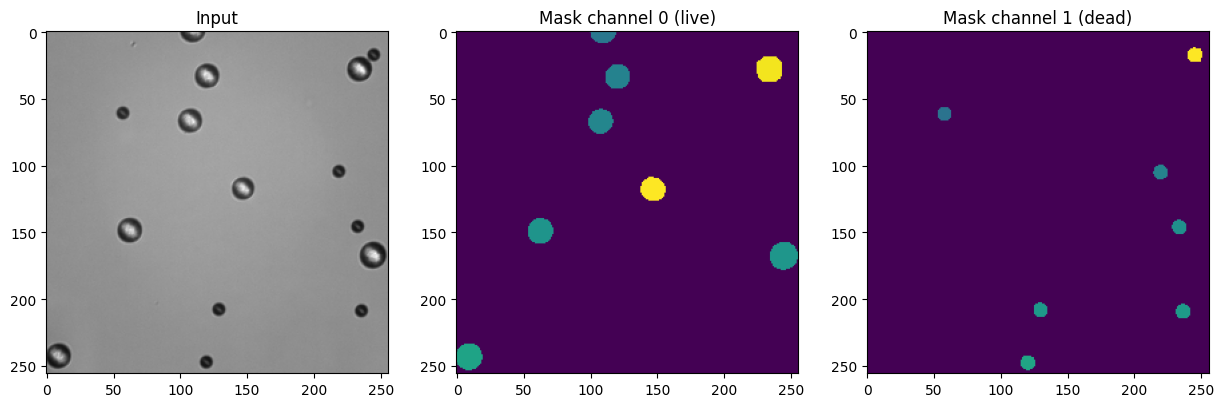

In [ ]:
# display
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(example_input[0], vmin=0, vmax=255, cmap='gray')
plt.title('Input')

plt.subplot(132)
plt.imshow(example_mask[0])
plt.title('Mask channel 0 (live)')

plt.subplot(133)
plt.imshow(example_mask[1])
plt.title('Mask channel 1 (dead)')

In [ ]:
# convert masks into objects needed by torch (pixel values already normalised).
boxes, labels, masks = helper.mask_image_to_instances(example_mask)

print('boxes:', boxes.shape, boxes.dtype)
print('labels:', labels.shape, labels.dtype)
print('masks:', masks.shape, masks.dtype)
print('labels =', labels)

boxes: torch.Size([15, 4]) torch.float32
labels: torch.Size([15]) torch.int64
masks: torch.Size([15, 256, 256]) torch.uint8
labels = tensor([1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2])


In [ ]:
class BeadsDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        """
        Parameters
        ----------
        root : str
          Path to dataset.
        """
        self.root = '/content/drive/MyDrive/Luke/data'
        # Define paths to input and mask folders
        input_folder = os.path.join(self.root, "input")
        mask_folder = os.path.join(self.root, "mask")

        # Get full file paths for input images and masks
        input_paths = []
        mask_paths = []

        # List all files in the input folder
        for file_name in sorted(os.listdir(input_folder)):
            if file_name.startswith("bead_"):
                input_path = os.path.join(input_folder, file_name)
                mask_path = os.path.join(mask_folder, file_name)
                if os.path.exists(mask_path):
                    input_paths.append(input_path)
                    mask_paths.append(mask_path)
                else:
                    print(f"Warning: Mask file not found for {file_name}")

        # Get full file paths for input images and masks
        """
        Task: populate self.input_paths and self.mask_paths with FULL file paths.
        """
        self.input_paths = input_paths
        self.mask_paths = mask_paths


    def __getitem__(self, idx):
        """
        Parameters
        ----------
        idx : int
          Input/mask pair index.
        """

        input_path = self.input_paths[idx]
        mask_path = self.mask_paths[idx]

        # Load TIFF image and mask
        image = io.imread(input_path)
        mask = io.imread(mask_path)

        # Debug: Print shapes before processing
        print(f"Image shape after loading: {image.shape}")
        print(f"Mask shape after loading: {mask.shape}")

        # Ensure channel-first format for image
        if len(image.shape) == 2:
            image = np.expand_dims(image, axis=0)
        elif len(image.shape) == 3 and image.shape[2] <= 3:
            image = np.transpose(image, (2, 0, 1))

        # Ensure channel-first format for mask
        if len(mask.shape) == 2:
            mask = np.expand_dims(mask, axis=0)
        elif len(mask.shape) == 3 and mask.shape[2] <= 3:
            mask = np.transpose(mask, (2, 0, 1))

        # Normalize image to [0, 1]
        image = image.astype(np.float32) / 255.0

        # Ensure mask is of type np.int32
        mask = mask.astype(np.int32)

        # Convert NumPy arrays into PyTorch tensors
        image = torch.as_tensor(image, dtype=torch.float32)
        mask = torch.as_tensor(mask, dtype=torch.int32)

        # data augmentation
        """
        Task: randomly augment data (e.g. flipping horizontally / vertically,
              rotation).
        """
        if torch.rand(1).item() > 0.5:  # Random horizontal flip
            image = torch.flip(image, dims=[2])
            mask = torch.flip(mask, dims=[2])
        if torch.rand(1).item() > 0.5:  # Random vertical flip
            image = torch.flip(image, dims=[1])
            mask = torch.flip(mask, dims=[1])
        if torch.rand(1).item() > 0.5:  # Random rotation (90 degrees)
            image = torch.rot90(image, k=1, dims=[1, 2])
            mask = torch.rot90(mask, k=1, dims=[1, 2])

        # convert mask into MaskRCNN output objects
        boxes, labels, masks = helper.mask_image_to_instances(mask)
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # assume none of the instances is crowd
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        return image, target


    def __len__(self):
        return len(self.input_paths)

In [ ]:
from torch.utils.data import DataLoader, random_split

# Define the collate_fn function
def collate_fn(batch):
    return tuple(zip(*batch))

# Initialize the dataset
dataset = BeadsDataset(root='/content/drive/MyDrive/Luke/data')

# Split the dataset into training and testing
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create data loaders
data_loader_train = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn,
)

data_loader_test = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
)

In [ ]:
data_loader_train, data_loader_test

(<torch.utils.data.dataloader.DataLoader at 0x79b9e123c790>,
 <torch.utils.data.dataloader.DataLoader at 0x79b9e1204990>)

In [ ]:
import torch
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection import maskrcnn_resnet50_fpn

# Define the number of classes (background + live + dead)
num_classes = 3

# Define the backbone and model
backbone = resnet_fpn_backbone('resnet50', pretrained=False)  # Do not use pretrained weights
model = MaskRCNN(backbone, num_classes=num_classes)

# Send the model to CUDA (if available)
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(TORCH_DEVICE)

# Construct an optimizer (Adam with learning rate 0.0001)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=0.0001)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
print(model)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

In [ ]:
def train_one_epoch(model, optimizer, data_loader_train, device):
    model.train()

    for images, targets in data_loader_train:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        loss_value = losses.item()

        if not math.isfinite(loss_value):
            print(f'Loss is {loss_value}, stopping training')
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        return losses

In [ ]:
# Define the backup directory in Google Drive
backup_path = "/content/drive/MyDrive/Luke"

# Create the directory if it doesn't exist
os.makedirs(backup_path, exist_ok=True)

# Training loop
start_epoch = 0
num_epochs = 100
save_epoch_interval = 10

for epoch in range(start_epoch + 1, num_epochs + 1):
    print(f'Epoch {epoch}/{num_epochs}', end='')

    # Train for one epoch
    losses = train_one_epoch(model, optimizer, data_loader_train, TORCH_DEVICE)
    print(f' losses: {losses:.4f}')

    # Save the model at specified intervals
    if epoch > 0 and epoch % save_epoch_interval == 0:
        print(f'Reached epoch {epoch}, saving model...')
        time_now_text = datetime.datetime.now().strftime('%Y-%m-%d')
        save_path = os.path.join(backup_path, f'{time_now_text}_epoch-{epoch}.pth')
        torch.save(model.state_dict(), save_path)
        print(f'Model saved at {save_path}')

Epoch 1/100Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
 losses: 30.8452
Epoch 2/100Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
 losses: 13.8130
Epoch 3/100Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
 losses: 12.2769
Epoch 4/100Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
 losses: 15.5736
Epoch 5/100Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
 losses: 7.1009
Epoch 6/100Image shape after loading: (256, 256)
Mask shape after loading: (2, 25

In [ ]:
import os
import torch
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

# Define the number of classes
num_classes = 3

# Define the model with the same architecture as during training
backbone = resnet_fpn_backbone('resnet50', pretrained=False)
model = MaskRCNN(backbone, num_classes=num_classes)

# Send the model to the appropriate device (CUDA or CPU)
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(TORCH_DEVICE)

# Find the latest saved model weights
backup_dir = '/content/drive/MyDrive/Luke'
saved_models = [f for f in os.listdir(backup_dir) if f.endswith("pth")]
if saved_models:
    # Sort by modification time to get the latest file
    saved_models.sort(key=lambda x: os.path.getmtime(os.path.join(backup_dir, x)))
    latest_model_path = os.path.join(backup_dir, saved_models[-1])
    print(f"Loading model weights from: {latest_model_path}")

    # Load the saved weights into the model
    model.load_state_dict(torch.load(latest_model_path, map_location=TORCH_DEVICE))
    print("Model weights loaded successfully.")
else:
    print("No saved model weights found in ./backup.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loading model weights from: /content/drive/MyDrive/Luke/2025-03-13_14-43-57_epoch-100.pth


<ipython-input-20-e442c15f0394>:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(latest_model_path, map_location=TORCH_DEVICE))


Model weights loaded successfully.


In [ ]:
# Switch the model to evaluation mode
model.eval()

# Get a batch of test images
images, targets = next(iter(data_loader_test))
test_images = [image.to(TORCH_DEVICE) for image in images]

# Perform inference
with torch.no_grad():
    pred = model(test_images)

# check `pred`
print(pred)

Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
Image shape after loading: (256, 256)
Mask shape after loading: (2, 256, 256)
[{'boxes': tensor([[  0.0000, 172.3185,  18.5977, 191.2723],
        [ 83.4074, 228.9438, 102.7324, 247.6576],
        [ 47.5099,  70.0507,  66.6061,  88.9651],
        [ 75.7605,  91.5069,  95.1135, 110.6334],
        [203.0294, 132.6850, 222.6675, 151.6935],
        [220.7186, 151.1578, 231.9824, 162.1522],
        [211.5117, 240.5569, 222.1778, 251.3261],
        [124.4635, 161.2669, 144.1944, 180.4697],
        [237.7287, 188.8179, 248.7946, 199.4842],
        [175.0241, 223.8846, 185.7975, 234.5889],
        [ 13.1674, 155.6532,  23.9040, 166.0178],
        [132.7917, 134.1951, 143.0582, 144.4901],
        [143.5125, 172.0967, 154.2085, 182.2692],
        [246.5295, 165.5370, 256.0000, 176.2412],
        [117.0751, 167.9414, 127.6865, 178.1183],
        [233.7452, 185.2554, 252.1401, 202.5810],
        [  0.0000,  12.3264,   6.

In [ ]:
# Extract predictions for the first image 
prediction = pred[0]

# Convert predictions to NumPy arrays
boxes = prediction['boxes'].cpu().numpy()  
labels = prediction['labels'].cpu().numpy()  y

# Check if 'scores' exists in the prediction dictionary
if 'scores' in prediction:
    scores = prediction['scores'].cpu().numpy()  
else:
    scores = None  

# Convert masks to NumPy array
masks = prediction['masks'].cpu().numpy()  

# Convert the input image to a NumPy array
image = test_images[0].cpu().permute(1, 2, 0).numpy()  

# If the image is 1 channel, add a channel dimension for visualization
if image.shape[2] == 1:
    image = image.squeeze(axis=2)  

# Print shapes for verification
print(f"Boxes shape: {boxes.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Scores shape: {scores.shape if scores is not None else 'N/A'}")
print(f"Masks shape: {masks.shape}")
print(f"Image shape: {image.shape}")

Boxes shape: (61, 4)
Labels shape: (61,)
Scores shape: (61,)
Masks shape: (61, 1, 256, 256)
Image shape: (256, 256)


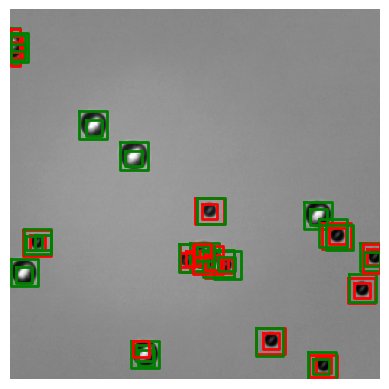

In [ ]:
import matplotlib.pyplot as plt

# Function to visualize predictions
def visualize_prediction(image, boxes, labels, scores=None, masks=None):
    # Plot the image
    plt.imshow(image, cmap='gray' if len(image.shape) == 2 else None)

    # Define a color map for labels
    label_to_color = {
        1: 'green',  # Live beads
        2: 'red',    # Dead beads
    }

    # Plot the predicted boxes with colors based on labels
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        color = label_to_color.get(label, 'blue')  
        plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], color=color, linewidth=2)

    # Plot the predicted masks (if available)
    if masks is not None:
        for mask in masks:
            mask = mask.squeeze()  # Remove the channel dimension
            plt.imshow(mask, alpha=0.001, cmap='viridis')

    plt.axis('off')
    plt.show()

# Visualize predictions
visualize_prediction(image, boxes, labels, scores, masks)